In [ ]:
pip install "cloudpathlib[s3]"

In [ ]:
!pip install opencv-python-headless

In [ ]:
import sys
sys.path.append("/FinalProject")
from pathlib import Path
from config import BUCKET_NAME, RAW_IMAGE_FOLDER
from cloudpathlib import S3Client, S3Path
import cv2
import matplotlib.pyplot as plt
import numpy as np

In [14]:
client = S3Client()
client.set_as_default_client()

In [16]:
S3_Bucket = S3Path(f's3://{BUCKET_NAME}')

In [18]:
raw_imgs_folder = S3_Bucket / RAW_IMAGE_FOLDER

In [20]:
all_imgs_path = [x for x in raw_imgs_folder.rglob('*.jpeg')]

In [21]:
one_img_path = all_imgs_path[0]
one_img_path

S3Path('s3://pneumonia-data-set-group-4/raw-images/test/NORMAL/IM-0001-0001.jpeg')

In [45]:
img = cv2.imread(one_img_path, 0)

In [46]:
img.shape

(1317, 1857)

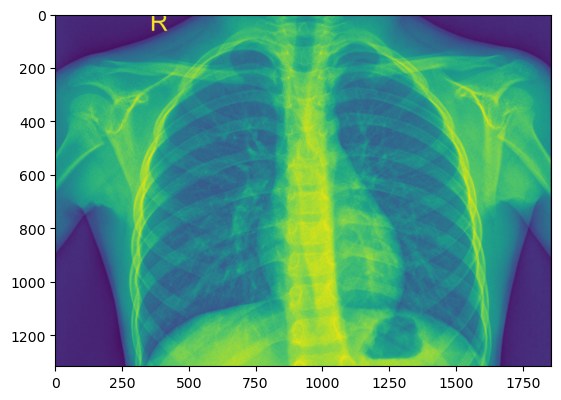

In [47]:
plt.imshow(img)
plt.show()

In [29]:
img.dtype

dtype('uint8')

In [31]:
img.max()

np.uint8(255)

In [34]:
def normalize_to_uint8(img: np.ndarray) -> np.ndarray:
    """
    this function takes and image and normalizes it to the min and max of 
    0 and 255. Then transoforms the type to 8 bit
    """
    img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX)
    return img.astype(np.uint8)

In [48]:
norm_img = normalize_to_uint8(img)

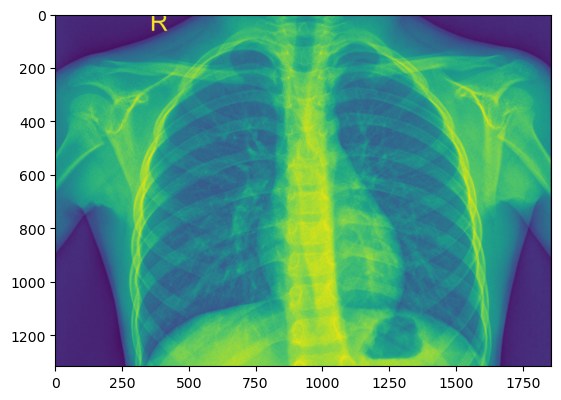

In [52]:
plt.imshow(norm_img)
plt.show()

In [50]:
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
enhanced_image = clahe.apply(norm_img)

In [58]:
def apply_clahe(img):
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced_image = clahe.apply(img)
    return enhanced_image

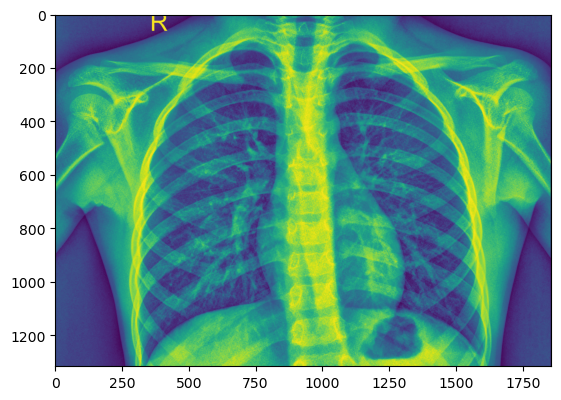

In [51]:
plt.imshow(enhanced_image)
plt.show()

In [56]:
resize_img = cv2.resize(enhanced_image, (512, 512), interpolation=cv2.INTER_LINEAR)

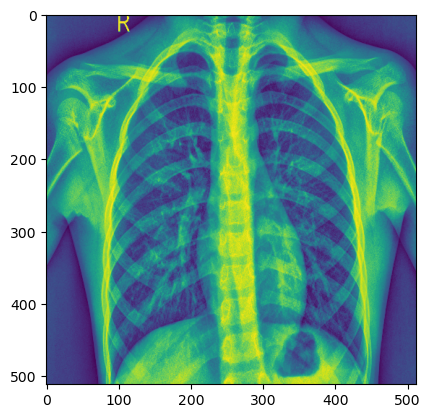

In [57]:
plt.imshow(resize_img)
plt.show()